* Overall Project: https://drive.google.com/drive/folders/101MM-1r6dhxcwRDr0z3l2KlSPXPJMn2L?usp=sharing

* Row Dataset: https://drive.google.com/drive/folders/1Did7IOB79PIkmKKDW5uw4sopedhLVgbx?usp=drive_link

* Split Dataset: https://drive.google.com/drive/folders/1K-vylVfjPhyiywYBJANQf-LC8mPExoo-?usp=sharing

* Weight Folder: https://drive.google.com/drive/folders/1VbOSqkSbGQ41YOmC4qxP1216kDTh_mW8?usp=sharing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import random
import shutil

# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Show Each Class Frequence**

In [ ]:
# paths
RAW_DATA = "/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note"
OUTPUT = "/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split"

before_count = {}
IMG_EXTS = (".jpg", ".png", ".jpeg")

# COUNT BEFORE SPLIT
print("\n📊 IMAGE COUNT BEFORE SPLIT:\n")

before_count = {}

for cls in sorted(os.listdir(f"{RAW_DATA}/images")):
    cls_path = os.path.join(RAW_DATA, "images", cls)
    if not os.path.isdir(cls_path):
        continue

    images = [f for f in os.listdir(cls_path) if f.lower().endswith(IMG_EXTS)]
    before_count[cls] = len(images)
    print(f"Class {cls}: {len(images)} images")

print("\nTotal images:", sum(before_count.values()))


📊 IMAGE COUNT BEFORE SPLIT:

Class fifty: 33 images
Class five: 32 images
Class five_hundred: 31 images
Class hundred: 32 images
Class ten: 32 images
Class thousand: 28 images
Class twenty: 32 images
Class two: 30 images
Class two_hundred: 25 images

Total images: 275


#Split the dataset in train(.7), test(.1) and val(.2)

In [ ]:
from collections import defaultdict

IMG_EXTS = (".jpg", ".png", ".jpeg")
TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1
random.seed(42)

# CREATE OUTPUT DIRECTORIES

for split in ["train", "val", "test"]:
    for sub in ["images", "labels"]:
        os.makedirs(f"{OUTPUT}/{sub}/{split}", exist_ok=True)


# SPLIT DATA

after_count = {
    "train": defaultdict(int),
    "val": defaultdict(int),
    "test": defaultdict(int),
}

for cls in before_count.keys():
    img_dir = os.path.join(RAW_DATA, "images", cls)
    label_dir = os.path.join(RAW_DATA, "labels", cls)

    images = [f for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXTS)]
    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, files in splits.items():
        for img in files:
            src_img = os.path.join(img_dir, img)
            src_lbl = os.path.join(label_dir, os.path.splitext(img)[0] + ".txt")

            shutil.copy(src_img, f"{OUTPUT}/images/{split}")
            if os.path.exists(src_lbl):
                shutil.copy(src_lbl, f"{OUTPUT}/labels/{split}")

            after_count[split][cls] += 1

# COUNT AFTER SPLIT

In [ ]:
print("\n IMAGE COUNT AFTER SPLIT:\n")

for split in ["train", "val", "test"]:
    print(f"--- {split.upper()} ---")
    total = 0
    for cls in sorted(after_count[split].keys()):
        count = after_count[split][cls]
        total += count
        print(f"Class {cls}: {count}")
    print(f"Total {split}: {total}\n")


 IMAGE COUNT AFTER SPLIT:

--- TRAIN ---
Class fifty: 23
Class five: 22
Class five_hundred: 21
Class hundred: 22
Class ten: 22
Class thousand: 19
Class twenty: 22
Class two: 21
Class two_hundred: 17
Total train: 189

--- VAL ---
Class fifty: 6
Class five: 6
Class five_hundred: 6
Class hundred: 6
Class ten: 6
Class thousand: 5
Class twenty: 6
Class two: 6
Class two_hundred: 5
Total val: 52

--- TEST ---
Class fifty: 4
Class five: 4
Class five_hundred: 4
Class hundred: 4
Class ten: 4
Class thousand: 4
Class twenty: 4
Class two: 3
Class two_hundred: 3
Total test: 34



#Randomly show some sample

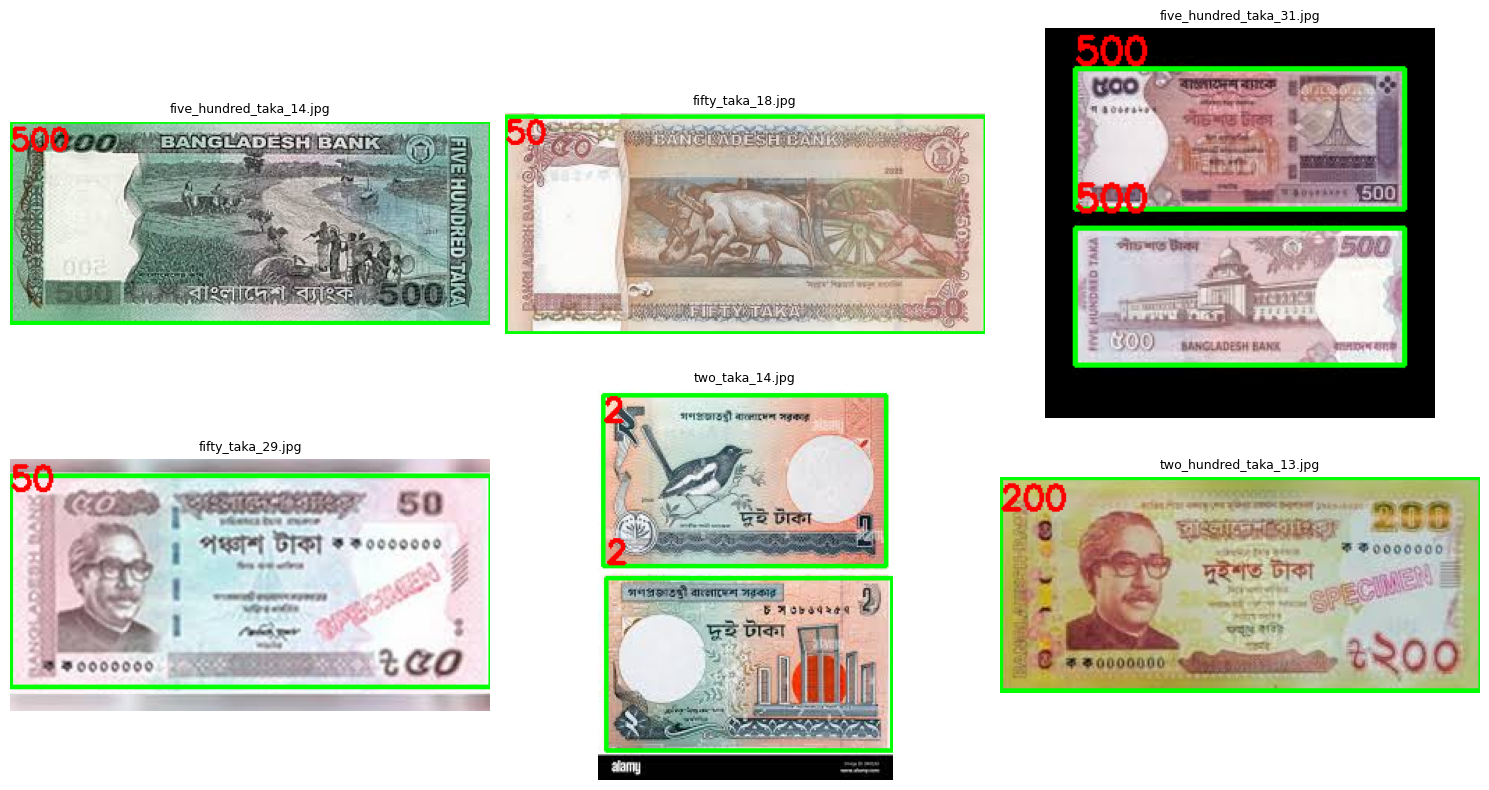

In [ ]:
import random
import cv2

DATASET = "/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split"
SPLIT = "train"   # train / val / test
NUM_IMAGES = 6
IMAGES_PER_ROW = 3

IMG_DIR = f"{DATASET}/images/{SPLIT}"
LBL_DIR = f"{DATASET}/labels/{SPLIT}"

IMG_EXTS = (".jpg", ".png", ".jpeg")

class_names = [
    "2", "5", "10", "20", "50",
    "100", "200", "500", "1000"
]

# PICK RANDOM IMAGES
images = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(IMG_EXTS)]
selected_images = random.sample(images, NUM_IMAGES)

# PLOT SETUP
rows = NUM_IMAGES // IMAGES_PER_ROW
plt.figure(figsize=(15, 8))

for idx, img_name in enumerate(selected_images):
    img_path = os.path.join(IMG_DIR, img_name)
    lbl_path = os.path.join(LBL_DIR, os.path.splitext(img_name)[0] + ".txt")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # draw labels
    if os.path.exists(lbl_path):
        with open(lbl_path, "r") as f:
            for line in f:
                cls_id, x, y, bw, bh = map(float, line.split())
                cls_id = int(cls_id)

                x1 = int((x - bw / 2) * w)
                y1 = int((y - bh / 2) * h)
                x2 = int((x + bw / 2) * w)
                y2 = int((y + bh / 2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    img,
                    class_names[cls_id],
                    (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 0, 0),
                    2
                )

    # subplot
    plt.subplot(rows, IMAGES_PER_ROW, idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name, fontsize=9)

plt.tight_layout()
plt.show()


#Install yolo model

In [ ]:
!pip install ultralytics
%matplotlib inline

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.0 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


#load pretrain yolo11 nano

In [ ]:
pretrained_model = YOLO("yolo11n.pt")

#Fine-tuning YOLO

In [ ]:
results = pretrained_model.train(
    data="/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,        # use GPU (set -1 for CPU)
    workers=8,
    patience=20,
    project="bangla_note_detection",
    name="yolo11n_v1"
)

Ultralytics 8.3.247 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo11n_v14, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

#Evaluation

In [ ]:
pretrained_model.val(
    data="/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/data.yaml",
    split="test"
)

Ultralytics 8.3.247 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 2.4±2.3 MB/s, size: 8.3 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/labels/test... 57 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 1.9it/s 30.7s
val: New cache created: /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.9it/s 2.1s
                   all         58         82      0.785      0.762      0.833      0.785
                     2          5          6          1      0.746      0.869        0.8
                     5          8         10      0.699        0.6      0.661      0.613
                    10          8         

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cbdf86cdd90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

Summary:
It shows how well your trained YOLO model performs on unseen data (test set). The most important metric here is mAP50–95 = 0.7849, which means your Bangla note detection model correctly detects and localizes banknotes about 78% of the time across strict IoU thresholds—this is a strong result for a first version. The precision (≈78.5%) indicates that when the model predicts a note, it is usually correct (low false positives), while the recall (≈76.2%) shows the model successfully finds most of the actual notes but still misses some. The per-class mAP (maps) reveals that notes like 200, 1000, and 20 are detected very well, whereas 5, 50, and 100 are weaker—mainly due to fewer samples and visual similarity. The small number of test instances per class (nt_per_class) also means results can fluctuate. Overall, the model is learning correctly, is usable, and can be improved further with more data and augmentation.

In [ ]:
pretrained_model.predict(
    source="/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test",
    conf=0.25,
    save=True
)



image 1/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/fifty_taka_16.jpg: 320x640 1 2, 1 50, 54.6ms
image 2/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/fifty_taka_17.jpg: 320x640 1 50, 1 500, 7.9ms
image 3/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/fifty_taka_20.jpg: 576x640 2 50s, 1 500, 48.0ms
image 4/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/fifty_taka_26.jpg: 576x640 1 50, 1 500, 21.4ms
image 5/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/five_hundred_taka_13.jpg: 288x640 1 50, 1 500, 103.3ms
image 6/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/five_hundred_taka_15.jpg: 544x640 2 500s, 137.6ms
image 7/58 /content/drive/MyDrive/Colab No

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '2', 1: '5', 2: '10', 3: '20', 4: '50', 5: '100', 6: '200', 7: '500', 8: '1000'}
 obb: None
 orig_img: array([[[250, 248, 255],
         [238, 236, 255],
         [250, 247, 255],
         ...,
         [250, 252, 255],
         [250, 252, 255],
         [248, 254, 255]],
 
        [[210, 207, 233],
         [181, 180, 206],
         [194, 190, 219],
         ...,
         [250, 250, 255],
         [248, 251, 255],
         [248, 252, 255]],
 
        [[208, 204, 239],
         [177, 176, 210],
         [186, 182, 218],
         ...,
         [230, 230, 254],
         [229, 232, 253],
         [230, 234, 253]],
 
        ...,
 
        [[186, 183, 222],
         [180, 177, 216],
         [174, 171, 210],
         ...,
         [167, 167, 203],
         [171, 173, 204],
         [214, 214, 244]],
 
        [[250, 246, 255],
         [244

In [ ]:
pretrained_model.predict(
    source="/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test",
    split="test"
)


image 1/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/fifty_taka_16.jpg: 320x640 1 2, 1 50, 13.8ms
image 2/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/fifty_taka_17.jpg: 320x640 1 50, 1 500, 9.7ms
image 3/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/fifty_taka_20.jpg: 576x640 2 50s, 1 500, 11.3ms
image 4/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/fifty_taka_26.jpg: 576x640 1 50, 1 500, 7.7ms
image 5/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/five_hundred_taka_13.jpg: 288x640 1 50, 1 500, 8.0ms
image 6/58 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/five_hundred_taka_15.jpg: 544x640 2 500s, 8.5ms
image 7/58 /content/drive/MyDrive/Colab Noteboo

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: '2', 1: '5', 2: '10', 3: '20', 4: '50', 5: '100', 6: '200', 7: '500', 8: '1000'}
 obb: None
 orig_img: array([[[250, 248, 255],
         [238, 236, 255],
         [250, 247, 255],
         ...,
         [250, 252, 255],
         [250, 252, 255],
         [248, 254, 255]],
 
        [[210, 207, 233],
         [181, 180, 206],
         [194, 190, 219],
         ...,
         [250, 250, 255],
         [248, 251, 255],
         [248, 252, 255]],
 
        [[208, 204, 239],
         [177, 176, 210],
         [186, 182, 218],
         ...,
         [230, 230, 254],
         [229, 232, 253],
         [230, 234, 253]],
 
        ...,
 
        [[186, 183, 222],
         [180, 177, 216],
         [174, 171, 210],
         ...,
         [167, 167, 203],
         [171, 173, 204],
         [214, 214, 244]],
 
        [[250, 246, 255],
         [244

#Confusion Matrix

Ultralytics 8.3.247 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,583,907 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 2.0±1.5 ms, read: 0.8±0.3 MB/s, size: 10.5 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/labels/test.cache... 57 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 58/58 10.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0it/s 3.9s
                   all         58         82      0.785      0.762      0.833      0.785
                     2          5          6          1      0.746      0.869        0.8
                     5          8         10      0.699        0.6      0.661      0.613
                    10          8         11      0.877      0.545      0.745      0.724
                    20          9         14      0.867      0.927      0.9

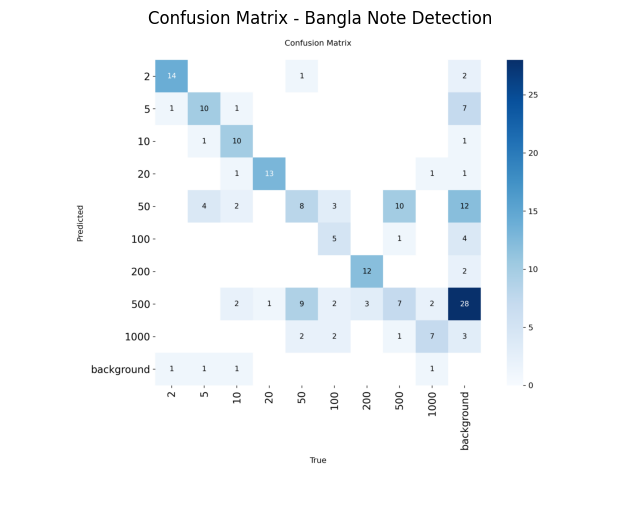

In [ ]:
import cv2

model = YOLO("/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/bangla_note_detection/yolo11n_v14/weights/best.pt")

# run validation again
model.val(
    data="/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/data.yaml",
    split="test",
    plots=True
)

# display confusion matrix
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/bangla_note_detection/yolo11n_v14/confusion_matrix.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix - Bangla Note Detection")
plt.show()


#Run inference on random test image


image 1/1 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/five_hundred_taka_8.jpg: 576x640 2 500s, 48.8ms
Speed: 7.4ms preprocess, 48.8ms inference, 4.5ms postprocess per image at shape (1, 3, 576, 640)

image 1/1 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/two_hundred_taka_9.jpg: 288x640 1 200, 36.2ms
Speed: 4.2ms preprocess, 36.2ms inference, 6.4ms postprocess per image at shape (1, 3, 288, 640)

image 1/1 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/fifty_taka_16.jpg: 320x640 1 2, 1 50, 58.6ms
Speed: 6.8ms preprocess, 58.6ms inference, 1.8ms postprocess per image at shape (1, 3, 320, 640)

image 1/1 /content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test/twenty_taka_21.jpg: 480x640 1 20, 12.0ms
Speed: 2.4ms preprocess, 12.0ms inference, 1.6ms postprocess per image at shape (1, 3

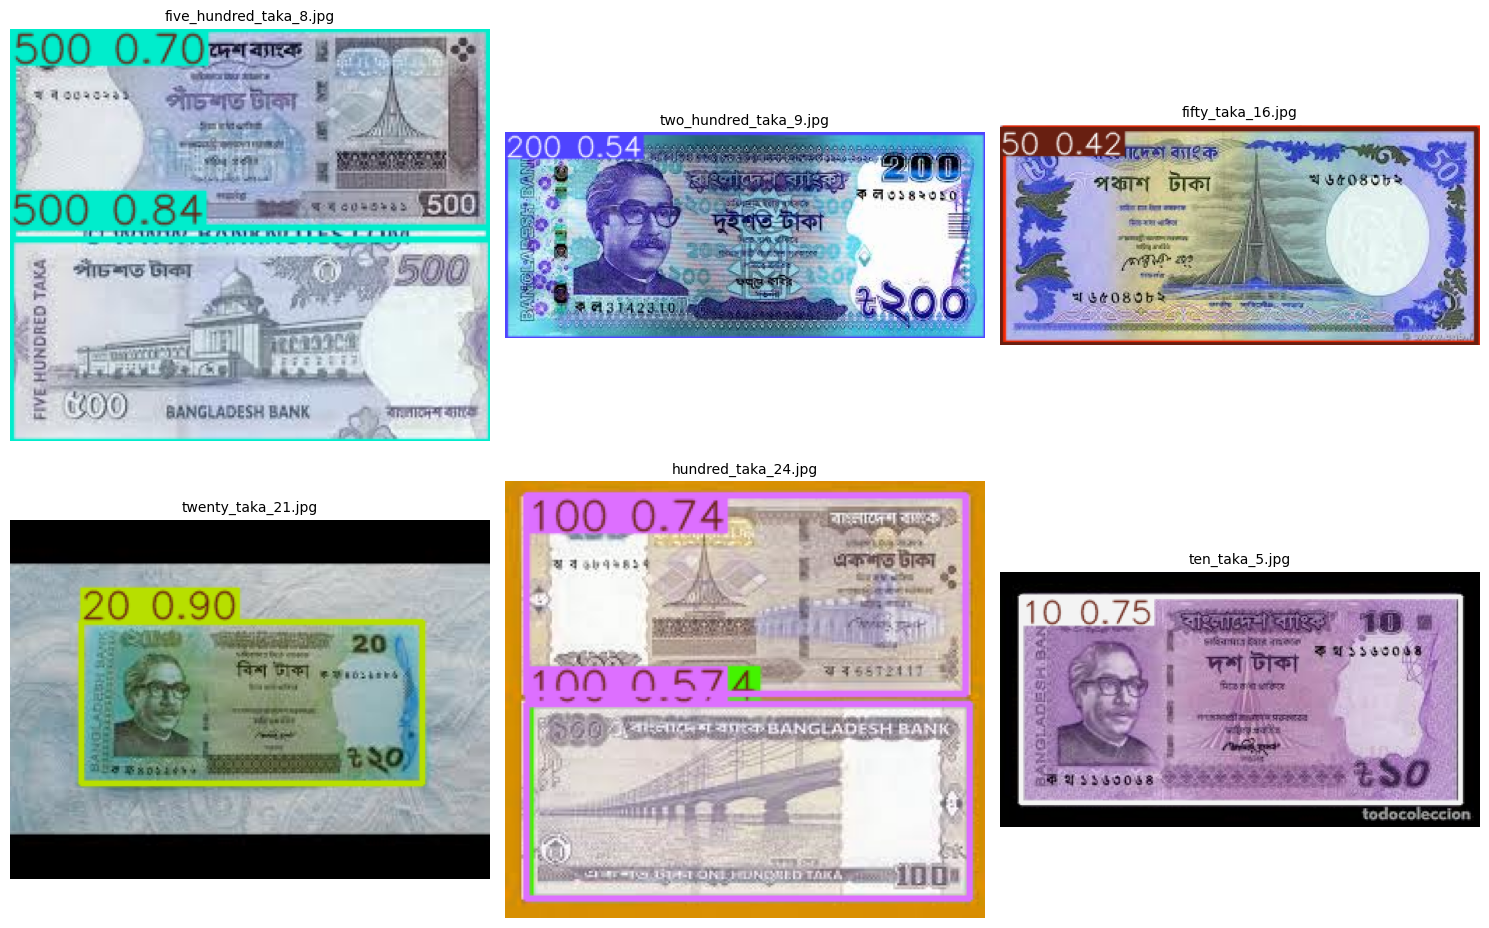

In [ ]:
import os
import random
from ultralytics import YOLO
import matplotlib.pyplot as plt


# PATH TO TRAINED MODEL
trained_model_path = "/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/bangla_note_detection/yolo11n_v14/weights/best.pt"
trained_model = YOLO(trained_model_path)


# PATH TO TEST IMAGES
TEST_IMAGES_DIR = "/content/drive/MyDrive/Colab Notebooks/Ostad/Ostad_Assignment/Dataset/bangal_note_split/images/test"
IMG_EXTS = (".jpg", ".png", ".jpeg")
test_images = [f for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(IMG_EXTS)]

# Pick 6 random images safely
NUM_IMAGES = min(6, len(test_images))
selected_images = random.sample(test_images, NUM_IMAGES)


# DISPLAY INFERENCE FOR 6 IMAGES
plt.figure(figsize=(15, 10))

for idx, img_name in enumerate(selected_images):
    TEST_IMAGE = os.path.join(TEST_IMAGES_DIR, img_name)

    # Run inference
    results = trained_model.predict(
        source=TEST_IMAGE,
        conf=0.25,
        save=False  # Do not save to disk, display directly
    )

    # Get image with boxes plotted
    img_with_boxes = results[0].plot()  # returns numpy array

    # Plot in grid
    plt.subplot(2, 3, idx + 1)
    plt.imshow(img_with_boxes)
    plt.axis("off")
    plt.title(img_name, fontsize=10)

plt.tight_layout()
plt.show()
